# Exemplo de treinamento para as bases de dados: Classificação e Regressão.

----



### 2. Carregamento das Bases de Dados
Agora, vamos carregar os arquivos CSV para inspecionar os dados.

In [31]:
import pandas as pd

base_ml = pd.read_csv('./base_discentes_semestre_ml.csv')
base_flat = pd.read_csv('./base_flat_por_aluno.csv')
base_seq = pd.read_csv('./base_sequencial_por_semestre.csv')

print("Base ML:")
display(base_ml.head())
print("Base Flat:")
display(base_flat.head())
print("Base Sequencial:")
display(base_seq.head())

Base ML:


,id_discente,ano_ingresso,periodo_ingresso,semestre_cronologico,renda,sexo_encoded,ano_nascimento,raca_encoded,escola_ens_medio_encoded,cotista_encoded,...,ECT2301_faltas,ECT2302_faltas,ECT2303_faltas,ECT2304_faltas,ECT2305_faltas,ECT2306_faltas,ECT2307_faltas,ECT2401_faltas,ECT2402_faltas,ECT2403_faltas
0,0003f4cc27ecd5ac049f3ec37a76195c,2022,2.0,1.0,1302.0,0,1983.0,5,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0003f4cc27ecd5ac049f3ec37a76195c,2022,2.0,2.0,1302.0,0,1983.0,5,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0012eec874bff4c326e63521912828fb,2010,1.0,1.0,1200.0,1,1991.0,4,-1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0012eec874bff4c326e63521912828fb,2010,1.0,2.0,1200.0,1,1991.0,4,-1,0,...,0.0,0.0,0.0,0.0,0.0,12.0,0.0,0.0,0.0,0.0
4,0012eec874bff4c326e63521912828fb,2010,1.0,3.0,1200.0,1,1991.0,4,-1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Base Flat:


,id_discente,concluiu,semestres_para_concluir,renda,sexo_encoded,ano_nascimento,raca_encoded,escola_ens_medio_encoded,cotista_encoded,possui_bolsa_pesquisa,...,s4_ECT2401_status,s4_ECT2402_nota,s4_ECT2402_status,s4_ECT2403_nota,s4_ECT2403_status,s4_faltas_no_periodo,s4_media_periodo,s4_reprovacoes_no_periodo,s4_total_faltas_acumulado,s4_total_reprovacoes_acumulado
0,0003f4cc27ecd5ac049f3ec37a76195c,0.0,2.0,1302.0,0,1983.0,5,2,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0
1,0012eec874bff4c326e63521912828fb,0.0,9.0,1200.0,1,1991.0,4,-1,0,0,...,0.0,0.0,0.0,0.0,0.0,54.0,2.02,0.0,153.0,0.0
2,002321f817fa95db1e0506e5320df513,0.0,15.0,4000.0,1,1991.0,1,-1,0,0,...,0.0,0.0,0.0,0.0,0.0,30.0,1.70,0.0,90.0,0.0
3,003f2bc2c3179baf0bea21a6f3d64d0c,1.0,8.0,5800.0,1,1995.0,5,-1,0,0,...,0.0,5.9,1.0,0.0,0.0,34.0,1.53,0.0,146.0,0.0
4,005826163b7c91f427b5b9e4b02edefd,0.0,6.0,3500.0,1,1990.0,5,-1,0,0,...,0.0,0.0,0.0,0.0,0.0,54.0,2.46,0.0,94.0,0.0


Base Sequencial:


,id_discente,ano_ingresso,periodo_ingresso,semestre_cronologico,renda,sexo_encoded,ano_nascimento,raca_encoded,escola_ens_medio_encoded,cotista_encoded,...,ECT2306_nota,ECT2306_status,ECT2307_nota,ECT2307_status,ECT2401_nota,ECT2401_status,ECT2402_nota,ECT2402_status,ECT2403_nota,ECT2403_status
0,0003f4cc27ecd5ac049f3ec37a76195c,2022,2.0,1.0,1302.0,0,1983.0,5,2,1,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0
1,0003f4cc27ecd5ac049f3ec37a76195c,2022,2.0,2.0,1302.0,0,1983.0,5,2,1,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0
2,0012eec874bff4c326e63521912828fb,2010,1.0,1.0,1200.0,1,1991.0,4,-1,0,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0
3,0012eec874bff4c326e63521912828fb,2010,1.0,2.0,1200.0,1,1991.0,4,-1,0,...,5.0,1,0.0,0,0.0,0,0.0,0,0.0,0
4,0012eec874bff4c326e63521912828fb,2010,1.0,3.0,1200.0,1,1991.0,4,-1,0,...,5.0,1,0.0,0,0.0,0,0.0,0,0.0,0


In [32]:
print("Base Sequencial (Amostra):")
display(base_seq.head())

# Verificar se há valores nulos no target antes de prosseguir
print(f"\nValores nulos em 'concluiu' na Base Flat: {base_flat['concluiu'].isna().sum()}")

Base Sequencial (Amostra):


,id_discente,ano_ingresso,periodo_ingresso,semestre_cronologico,renda,sexo_encoded,ano_nascimento,raca_encoded,escola_ens_medio_encoded,cotista_encoded,...,ECT2306_nota,ECT2306_status,ECT2307_nota,ECT2307_status,ECT2401_nota,ECT2401_status,ECT2402_nota,ECT2402_status,ECT2403_nota,ECT2403_status
0,0003f4cc27ecd5ac049f3ec37a76195c,2022,2.0,1.0,1302.0,0,1983.0,5,2,1,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0
1,0003f4cc27ecd5ac049f3ec37a76195c,2022,2.0,2.0,1302.0,0,1983.0,5,2,1,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0
2,0012eec874bff4c326e63521912828fb,2010,1.0,1.0,1200.0,1,1991.0,4,-1,0,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0
3,0012eec874bff4c326e63521912828fb,2010,1.0,2.0,1200.0,1,1991.0,4,-1,0,...,5.0,1,0.0,0,0.0,0,0.0,0,0.0,0
4,0012eec874bff4c326e63521912828fb,2010,1.0,3.0,1200.0,1,1991.0,4,-1,0,...,5.0,1,0.0,0,0.0,0,0.0,0,0.0,0



Valores nulos em 'concluiu' na Base Flat: 130


### 3. Preparação e Treinamento do Modelo
Seguindo a documentação, vamos usar a `base_flat` para prever a conclusão do curso, separando o teste por alunos que ingressaram a partir de 2015 e antes de 2024.

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# 1. Preparar dados: remover ativos (NaN no concluiu)
df_modeling = base_flat.dropna(subset=['concluiu']).copy()

# 2. Obter ano_ingresso e aplicar o filtro solicitado (2015 a 2024)
df_ingresso = base_ml[['id_discente', 'ano_ingresso']].drop_duplicates()
df_modeling = df_modeling.merge(df_ingresso, on='id_discente', how='left')
df_filtered = df_modeling[(df_modeling['ano_ingresso'] >= 2015) & (df_modeling['ano_ingresso'] <= 2024)]

# 3. Definir features (X) focando APENAS em desempenho acadêmico
# Removemos explicitamente dados socioeconômicos e demográficos
socio_demo_cols = ['renda', 'sexo_encoded', 'ano_nascimento', 'raca_encoded',
                   'escola_ens_medio_encoded', 'cotista_encoded', 'sexo_encoded.1']
drop_cols = ['id_discente', 'concluiu', 'semestres_para_concluir', 'semestres_para_concluir.1', 'ano_ingresso'] + socio_demo_cols

X = df_filtered.drop(columns=[c for c in drop_cols if c in df_filtered.columns])
y = df_filtered['concluiu']

# 4. Divisão em Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Treinamento
clf = RandomForestClassifier(random_state=42, n_estimators=100)
clf.fit(X_train, y_train)

# 6. Avaliação
y_pred = clf.predict(X_test)
print(f"Resultados Classificação (Apenas Desempenho - 2015-2024):")
print(classification_report(y_test, y_pred))

Resultados Classificação (Apenas Desempenho - 2015-2024):
              precision    recall  f1-score   support

         0.0       0.89      0.88      0.89       287
         1.0       0.82      0.83      0.82       181

    accuracy                           0.86       468
   macro avg       0.85      0.86      0.85       468
weighted avg       0.86      0.86      0.86       468



### 5. Preparação do Modelo Sequencial (LSTM)
Vamos transformar a base sequencial em tensores tridimensionais `(amostras, passos_no_tempo, features)` para alimentar uma LSTM.

In [51]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from sklearn.model_selection import train_test_split

# 1. Preparação da Base Sequencial com Filtro 2015-2024
# Garantir que temos o target 'concluiu' e o 'ano_ingresso' para o filtro
df_seq_mod = base_seq.copy()
if 'concluiu' not in df_seq_mod.columns:
    df_seq_mod = df_seq_mod.merge(base_flat[['id_discente', 'concluiu']], on='id_discente', how='left')

# Filtro temporal antes da criação de sequências
df_seq_mod = df_seq_mod.dropna(subset=['concluiu'])
df_seq_filtered = df_seq_mod[(df_seq_mod['ano_ingresso'] >= 2015) & (df_seq_mod['ano_ingresso'] <= 2024)]

def create_sequences(df):
    feat_cols = [c for c in df.columns if c not in ['id_discente', 'concluiu', 'ano_ingresso', 'status_curso_encoded', 'periodo_ingresso']]
    sequences = []
    targets = []
    for _, group in df.sort_values(['id_discente', 'semestre_cronologico']).groupby('id_discente'):
        sequences.append(group[feat_cols].values)
        targets.append(group['concluiu'].iloc[0])
    return sequences, np.array(targets)

X_seq, y_seq = create_sequences(df_seq_filtered)

# 2. Divisão Aleatória padronizada
X_train_list, X_test_list, y_train_seq, y_test_seq = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42)

# 3. Padding
X_train_pad = pad_sequences(X_train_list, dtype='float32', padding='post')
X_test_pad = pad_sequences(X_test_list, dtype='float32', padding='post', maxlen=X_train_pad.shape[1])

# 4. Modelo LSTM
model_lstm = Sequential([
    Input(shape=(X_train_pad.shape[1], X_train_pad.shape[2])),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_lstm.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,137 (137.25 KB)

 Trainable params: 35,137 (137.25 KB)

 Non-trainable params: 0 (0.00 B)

### 6. Treinamento e Avaliação do Modelo Sequencial
Finalizando o treinamento da rede neural para predição baseada no histórico temporal.

In [35]:
# Treinamento do modelo LSTM
history = model_lstm.fit(
    X_train_pad, y_train_seq,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Avaliação final no conjunto de teste sequencial
loss, accuracy = model_lstm.evaluate(X_test_pad, y_test_seq, verbose=0)
print(f"\nAcurácia do Modelo LSTM no Teste: {accuracy:.2f}")

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6332 - loss: 0.6502 - val_accuracy: 0.7433 - val_loss: 0.5407
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6914 - loss: 0.5714 - val_accuracy: 0.7487 - val_loss: 0.5028
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6908 - loss: 0.5558 - val_accuracy: 0.7273 - val_loss: 0.5052
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6742 - loss: 0.5578 - val_accuracy: 0.7380 - val_loss: 0.4897
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6974 - loss: 0.5397 - val_accuracy: 0.7594 - val_loss: 0.4846
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7188 - loss: 0.5261 - val_accuracy: 0.7594 - val_loss: 0.4765
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7271 - loss: 0.5209 - val_accuracy: 0.7701 - val_loss: 0.4594
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7134 - loss: 0.5232 - val_accuracy: 0.7540 - val_loss

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


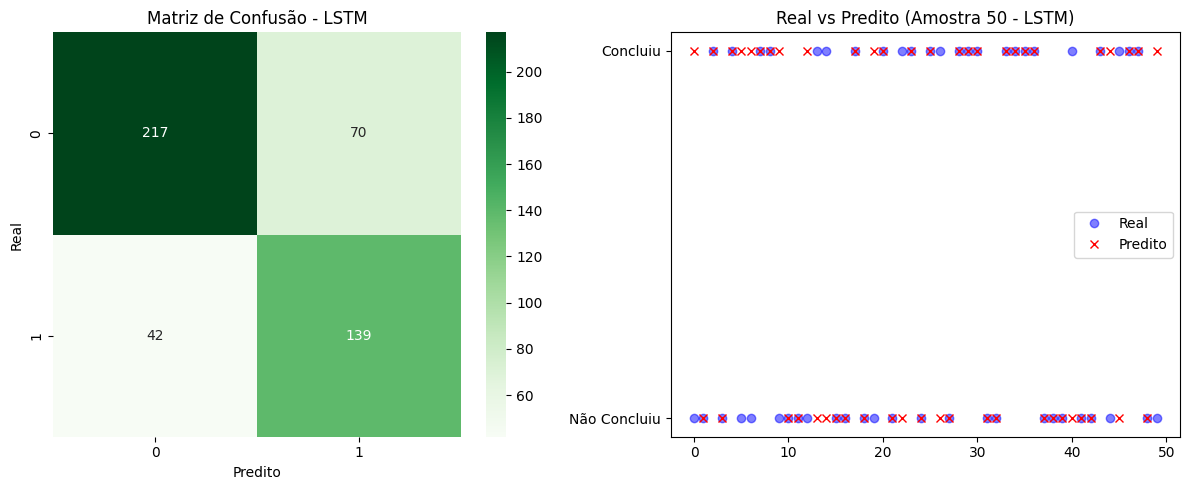

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Obter predições (probabilidades) e converter para classes (0 ou 1)
y_pred_lstm_prob = model_lstm.predict(X_test_pad)
y_pred_lstm = (y_pred_lstm_prob > 0.5).astype(int).flatten()

# 2. Gerar Matriz de Confusão
cm_lstm = confusion_matrix(y_test_seq, y_pred_lstm)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Matriz de Confusão
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Greens', ax=ax[0])
ax[0].set_title('Matriz de Confusão - LSTM')
ax[0].set_xlabel('Predito')
ax[0].set_ylabel('Real')

# Plot 2: Comparativo Real vs Predito (Amostra de 50 alunos)
plt.subplot(1, 2, 2)
plt.plot(y_test_seq[:50], 'bo', label='Real', alpha=0.5)
plt.plot(y_pred_lstm[:50], 'rx', label='Predito')
plt.title('Real vs Predito (Amostra 50 - LSTM)')
plt.yticks([0, 1], ['Não Concluiu', 'Concluiu'])
plt.legend()

plt.tight_layout()
plt.show()

### 5. Preparação para Modelo Sequencial
Agora, vamos utilizar a `base_sequencial_por_semestre.csv` para criar janelas temporais por aluno, conforme a orientação para modelos LSTM/GRU.

In [37]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import StandardScaler

# Filtrar alunos ativos e obter labels da base flat
labels = base_flat[['id_discente', 'concluiu']].dropna()
df_seq_labeled = base_seq.merge(labels, on='id_discente', how='inner')

# Ordenar por id e semestre para garantir a sequência temporal
df_seq_labeled = df_seq_labeled.sort_values(['id_discente', 'semestre_cronologico'])

# Identificar features sequenciais (excluindo IDs e alvos)
features_seq = [col for col in df_seq_labeled.columns if col not in ['id_discente', 'concluiu', 'status_curso_encoded']]

# Escalonamento das features
scaler = StandardScaler()
df_seq_labeled[features_seq] = scaler.fit_transform(df_seq_labeled[features_seq])

print(f"Formato da base sequencial processada: {df_seq_labeled.shape}")
print(f"Número de features: {len(features_seq)}")

Formato da base sequencial processada: (25500, 69)
Número de features: 66


### 3. Preparação dos Dados (Base Flat)
Conforme a documentação, vamos preparar os dados para prever se um aluno concluirá o curso (`concluiu`).

In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split

# 1. Limpeza inicial: Remover alunos sem label (ativos)
df_modeling = base_flat.dropna(subset=['concluiu']).copy()

# 2. Obter ano_ingresso e aplicar o filtro (2015 a 2024)
df_ingresso = base_ml[['id_discente', 'ano_ingresso']].drop_duplicates()
df_modeling = df_modeling.merge(df_ingresso, on='id_discente', how='left')

# Filtro de tempo solicitado: >= 2015 e <= 2024
df_filtered = df_modeling[(df_modeling['ano_ingresso'] >= 2015) & (df_modeling['ano_ingresso'] <= 2024)]

# 3. Definição de Features e Target
# Removendo colunas de identificação, targets e ano_ingresso para o treino
drop_cols = ['id_discente', 'concluiu', 'semestres_para_concluir', 'ano_ingresso']
X = df_filtered.drop(columns=[c for c in drop_cols if c in df_filtered.columns])
y = df_filtered['concluiu']

# 4. Divisão Treino/Teste Aleatória (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Filtro aplicado: Ingresso entre 2015 e 2024")
print(f"Tamanho do treino: {len(X_train)}")
print(f"Tamanho do teste: {len(X_test)}")

Filtro aplicado: Ingresso entre 2015 e 2024
Tamanho do treino: 1869
Tamanho do teste: 468


### 4. Treinamento do Modelo
Utilizaremos um Random Forest como modelo inicial para classificação.

In [39]:
model = RandomForestClassifier(random_state=42, n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Relatório de Classificação:")
print(classification_report(y_test, y_pred))
print(f"Acurácia: {accuracy_score(y_test, y_pred):.2f}")

Relatório de Classificação:
              precision    recall  f1-score   support

         0.0       0.90      0.85      0.87      1480
         1.0       0.76      0.84      0.80       857

    accuracy                           0.84      2337
   macro avg       0.83      0.84      0.84      2337
weighted avg       0.85      0.84      0.85      2337

Acurácia: 0.84


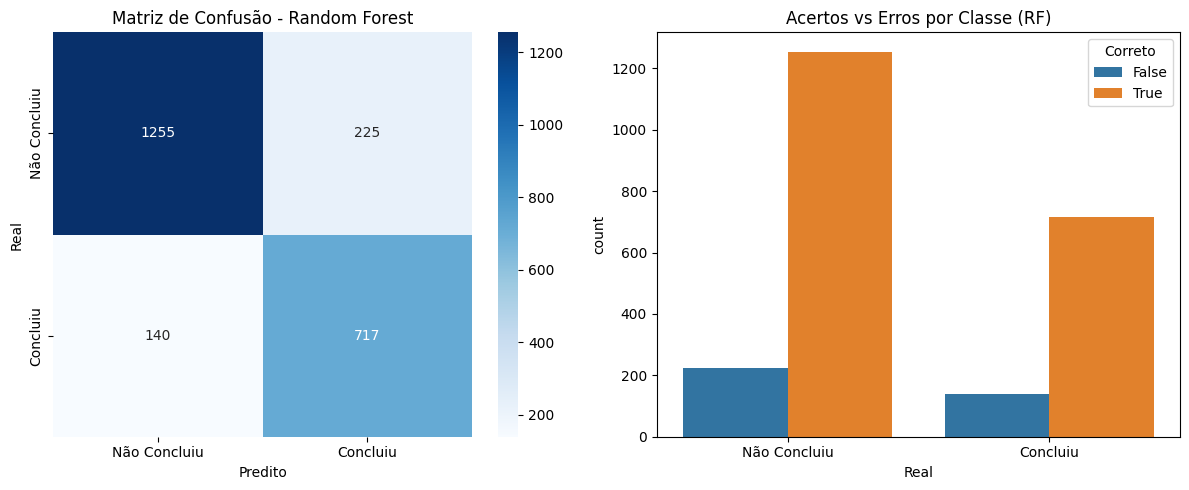

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Gerar Matriz de Confusão para o Random Forest
cm_rf = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Matriz de Confusão
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Matriz de Confusão - Random Forest')
ax[0].set_xlabel('Predito')
ax[0].set_ylabel('Real')
ax[0].set_xticklabels(['Não Concluiu', 'Concluiu'])
ax[0].set_yticklabels(['Não Concluiu', 'Concluiu'])

# Plot 2: Distribuição de Acertos vs Erros
results_rf = pd.DataFrame({'Real': y_test, 'Predito': y_pred})
results_rf['Correto'] = results_rf['Real'] == results_rf['Predito']
sns.countplot(x='Real', hue='Correto', data=results_rf, ax=ax[1])
ax[1].set_title('Acertos vs Erros por Classe (RF)')
ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(['Não Concluiu', 'Concluiu'])

plt.tight_layout()
plt.show()

----
#Regressores
----

In [49]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Filtrar apenas alunos que concluíram o curso
df_reg = base_flat[base_flat['concluiu'] == 1].copy()

# 2. Obter ano_ingresso e aplicar o filtro (2015 a 2024) para consistência
df_ingresso = base_ml[['id_discente', 'ano_ingresso']].drop_duplicates()
df_reg = df_reg.merge(df_ingresso, on='id_discente', how='left')
df_reg = df_reg[(df_reg['ano_ingresso'] >= 2015) & (df_reg['ano_ingresso'] <= 2024)]

# 3. Definir target e remover colunas irrelevantes/socioeconômicas
socio_demo_cols = ['renda', 'sexo_encoded', 'ano_nascimento', 'raca_encoded',
                   'escola_ens_medio_encoded', 'cotista_encoded', 'sexo_encoded.1']
drop_cols_reg = ['id_discente', 'concluiu', 'semestres_para_concluir', 'semestres_para_concluir.1', 'ano_ingresso'] + socio_demo_cols

X_reg = df_reg.drop(columns=[c for c in drop_cols_reg if c in df_reg.columns])
y_reg = df_reg['semestres_para_concluir']

# 4. Divisão Treino/Teste
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 5. Treinamento
regressor = RandomForestRegressor(n_estimators=100, random_state=42)
regressor.fit(X_train_r, y_train_r)

# 6. Predição e Métricas
y_pred_r = regressor.predict(X_test_r)
mae = mean_absolute_error(y_test_r, y_pred_r)
r2 = r2_score(y_test_r, y_pred_r)

print(f"Regressor Tempo de Conclusão (Filtro 2015-2024):")
print(f"MAE: {mae:.2f} semestres")
print(f"R²: {r2:.2f}")

Regressor Tempo de Conclusão (Filtro 2015-2024):
MAE: 1.41 semestres
R²: 0.61


### Análise de Resíduos e Padrões de Erro
Nesta seção, identificamos quais variáveis estão mais correlacionadas com os erros do modelo de regressão.

In [47]:
import pandas as pd
import numpy as np

# 1. Criar DataFrame de análise combinando features de teste e erros
analysis_df = X_test_r.copy()
analysis_df['erro_real'] = y_test_r - y_pred_r
analysis_df['erro_absoluto'] = np.abs(analysis_df['erro_real'])

# 2. Calcular correlação do erro absoluto com as features
# Isso ajuda a ver se o erro aumenta conforme certas variáveis aumentam
correlations = analysis_df.corr()['erro_absoluto'].sort_values(ascending=False)

print("Top 10 Variáveis mais associadas a erros maiores (Correlação com Erro Absoluto):")
display(correlations.head(11)) # 11 para pular o próprio erro_absoluto



Top 10 Variáveis mais associadas a erros maiores (Correlação com Erro Absoluto):


,erro_absoluto
erro_absoluto,1.000000
erro_real,0.301693
s2_total_faltas_acumulado,0.172564
s4_total_faltas_acumulado,0.169916
s2_ECT2307_nota,0.155534
s2_ECT2307_status,0.151827
s1_ECT2307_nota,0.136191
s3_total_faltas_acumulado,0.135067
s2_faltas_no_periodo,0.132469
s1_ECT2307_status,0.131551


### Treinamento Restrito aos Primeiros 2 Semestres
Nesta etapa, filtramos os dados para utilizar apenas informações disponíveis até o final do segundo semestre de cada discente.

In [50]:
# Ajuste do modelo Early Warning (2 semestres) - Padronizado

# 1. Definir colunas de desempenho S1 e S2
cols_performance = [c for c in base_flat.columns if c.startswith('s1_') or c.startswith('s2_')]
cols_to_keep = ['id_discente', 'concluiu', 'semestres_para_concluir'] + cols_performance

# 2. Filtrar base por período de ingresso (2015-2024)
df_early = base_flat[cols_to_keep].dropna(subset=['concluiu']).copy()
df_ingresso = base_ml[['id_discente', 'ano_ingresso']].drop_duplicates()
df_early = df_early.merge(df_ingresso, on='id_discente', how='left')
df_filtered_early = df_early[(df_early['ano_ingresso'] >= 2015) & (df_early['ano_ingresso'] <= 2024)]

# 3. Remover socioeconômicos e identificadores
socio_demo_cols = ['renda', 'sexo_encoded', 'ano_nascimento', 'raca_encoded', 'escola_ens_medio_encoded', 'cotista_encoded']
X_early_p = df_filtered_early.drop(columns=[c for c in ['id_discente', 'concluiu', 'semestres_para_concluir', 'ano_ingresso'] + socio_demo_cols if c in df_filtered_early.columns])
y_early_p = df_filtered_early['concluiu']

# 4. Divisão Aleatória
from sklearn.model_selection import train_test_split
X_train_ep, X_test_ep, y_train_ep, y_test_ep = train_test_split(X_early_p, y_early_p, test_size=0.2, random_state=42)

# 5. Treinamento
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
clf_early_p = RandomForestClassifier(random_state=42, n_estimators=100)
clf_early_p.fit(X_train_ep, y_train_ep)

print("Early Warning (2 Semestres) - Filtro 2015-2024 + Split Aleatório:")
print(classification_report(y_test_ep, clf_early_p.predict(X_test_ep)))

Early Warning (2 Semestres) - Filtro 2015-2024 + Split Aleatório:
              precision    recall  f1-score   support

         0.0       0.82      0.82      0.82       287
         1.0       0.72      0.71      0.71       181

    accuracy                           0.78       468
   macro avg       0.77      0.76      0.77       468
weighted avg       0.78      0.78      0.78       468



In [45]:
# 4. Ajustar Modelo Sequencial (LSTM) para 2 semestres
# Filtramos a base sequencial para pegar apenas os registros onde semestre_cronologico <= 2
df_seq_2sem = df_seq_filtered[df_seq_filtered['semestre_cronologico'] <= 2]

X_seq_2, y_seq_2 = create_sequences(df_seq_2sem)

# Padding e Split (maxlen agora será fixo em 2)
X_train_l2, X_test_l2, y_train_l2, y_test_l2 = train_test_split(X_seq_2, y_seq_2, test_size=0.2, random_state=42)
X_train_p2 = pad_sequences(X_train_l2, dtype='float32', padding='post', maxlen=2)
X_test_p2 = pad_sequences(X_test_l2, dtype='float32', padding='post', maxlen=2)

# Re-treinar LSTM Simplificada
model_lstm_early = Sequential([
    Input(shape=(2, X_train_p2.shape[2])),
    LSTM(32, return_sequences=False),
    Dense(1, activation='sigmoid')
])

model_lstm_early.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_lstm_early.fit(X_train_p2, y_train_l2, epochs=5, batch_size=32, verbose=0)

_, acc_early = model_lstm_early.evaluate(X_test_p2, y_test_l2, verbose=0)
print(f"\nAcurácia LSTM (2 Semestres): {acc_early:.2f}")


Acurácia LSTM (2 Semestres): 0.67


### Regressão Early Warning (2 Semestres)
Treinamento de um regressor para prever o tempo total de formatura usando apenas dados do 1º e 2º semestres.

In [46]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Filtrar concluintes e limpar colunas problemáticas que causam vazamento
# Precisamos garantir que NENHUMA coluna de tempo de conclusão ou target futuro esteja no X
df_reg_early = base_flat[base_flat['concluiu'] == 1][cols_to_keep].copy()

# Identificar e remover todas as variações de 'semestres_para_concluir' que podem estar na base
leakage_cols = [c for c in df_reg_early.columns if 'semestres_para_concluir' in c]
print(f"Colunas de vazamento removidas: {leakage_cols}")

# 2. Definir Features e Target
X_reg_e = df_reg_early.drop(columns=['id_discente', 'concluiu'] + leakage_cols)
y_reg_e = df_reg_early['semestres_para_concluir']

# 3. Split Treino/Teste
X_train_re, X_test_re, y_train_re, y_test_re = train_test_split(X_reg_e, y_reg_e, test_size=0.2, random_state=42)

# 4. Treino
regressor_early = RandomForestRegressor(n_estimators=100, random_state=42)
regressor_early.fit(X_train_re, y_train_re)

# 5. Avaliação
y_pred_re = regressor_early.predict(X_test_re)
mae_e = mean_absolute_error(y_test_re, y_pred_re)
r2_e = r2_score(y_test_re, y_pred_re)

print(f"\nResultados Corrigidos (Regressão 2 Semestres):")
print(f"Erro Médio Absoluto (MAE): {mae_e:.2f} semestres")
print(f"R² Score: {r2_e:.2f}")

Colunas de vazamento removidas: ['semestres_para_concluir']

Resultados Corrigidos (Regressão 2 Semestres):
Erro Médio Absoluto (MAE): 2.01 semestres
R² Score: 0.35
